# Extended Features Test

This notebook demonstrates the new features added to the `dirac_solver` library, including scalar and Coulomb potentials, and absorbing boundary conditions. It also includes a 2D simulation to test the extended plotting capabilities.

In [10]:
import sys
sys.path.append('..')
import numpy as np
from dirac_solver.geometry import Grid
from dirac_solver.initial_state import GaussianPacket, ConstantSpinor
from dirac_solver.core import DiracProblemBuilder, DiracSolver
from dirac_solver import _core

## 1. Scalar Potential Example

DiracSolver initialized with C++ 'FDTDLeapfrogIntegrator' engine.
Running simulation for 10000 steps...
  Step 10/10000 complete.
  Step 20/10000 complete.
  Step 30/10000 complete.
  Step 40/10000 complete.
  Step 50/10000 complete.
  Step 60/10000 complete.
  Step 70/10000 complete.
  Step 80/10000 complete.
  Step 90/10000 complete.
  Step 100/10000 complete.
  Step 110/10000 complete.
  Step 120/10000 complete.
  Step 130/10000 complete.
  Step 140/10000 complete.
  Step 150/10000 complete.
  Step 160/10000 complete.
  Step 170/10000 complete.
  Step 180/10000 complete.
  Step 190/10000 complete.
  Step 200/10000 complete.
  Step 210/10000 complete.
  Step 220/10000 complete.
  Step 230/10000 complete.
  Step 240/10000 complete.
  Step 250/10000 complete.
  Step 260/10000 complete.
  Step 270/10000 complete.
  Step 280/10000 complete.
  Step 290/10000 complete.
  Step 300/10000 complete.
  Step 310/10000 complete.
  Step 320/10000 complete.
  Step 330/10000 complete.
  Step 340/100

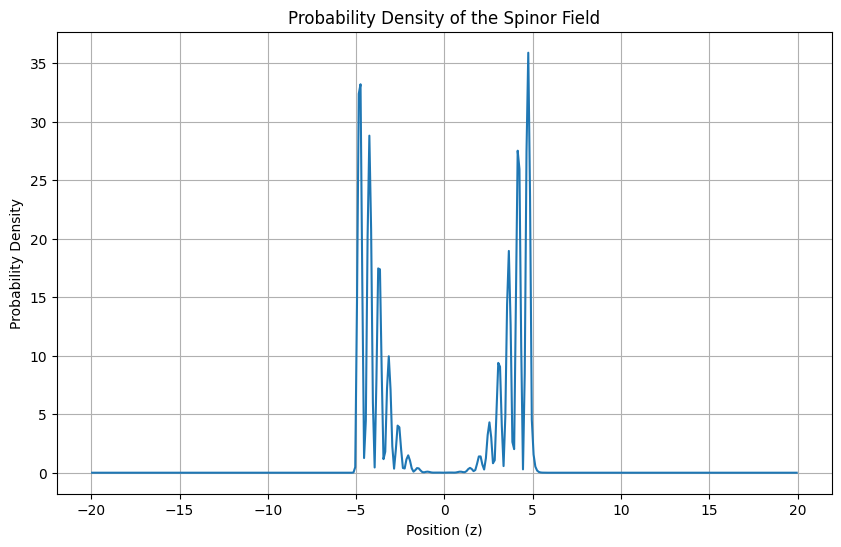

In [11]:
shape = (400,)
spacing = (0.1,)
grid = Grid(shape, spacing)

constant_spinor = ConstantSpinor(momentum=[10, 0, 0])
initial_state = GaussianPacket(constant_spinor, center=[0, 0, 0], spatial_width=1.0)

def potential_well(r):
    x = r[0]
    if -5 < x < 5:
        return 0.0
    return 20.0

potential = _core.ScalarPotential(potential_well)
boundary_condition = _core.AbsorbingBoundary(strength=0.1)

problem = DiracProblemBuilder() \
    .set_grid(grid) \
    .set_initial_state(initial_state) \
    .set_potential(potential) \
    .set_boundary_condition(boundary_condition) \
    .set_time_parameters(time_step=0.001, total_time=10.0) \
    .build()

solver = DiracSolver(problem)
solver.run_simulation()
solver.plot_probability_density()

## 2. Coulomb Potential Example

DiracSolver initialized with C++ 'FDTDLeapfrogIntegrator' engine.
Running simulation for 2000 steps...
  Step 10/2000 complete.
  Step 20/2000 complete.
  Step 30/2000 complete.
  Step 40/2000 complete.
  Step 50/2000 complete.
  Step 60/2000 complete.
  Step 70/2000 complete.
  Step 80/2000 complete.
  Step 90/2000 complete.
  Step 100/2000 complete.
  Step 110/2000 complete.
  Step 120/2000 complete.
  Step 130/2000 complete.
  Step 140/2000 complete.
  Step 150/2000 complete.
  Step 160/2000 complete.
  Step 170/2000 complete.
  Step 180/2000 complete.
  Step 190/2000 complete.
  Step 200/2000 complete.
  Step 210/2000 complete.
  Step 220/2000 complete.
  Step 230/2000 complete.
  Step 240/2000 complete.
  Step 250/2000 complete.
  Step 260/2000 complete.
  Step 270/2000 complete.
  Step 280/2000 complete.
  Step 290/2000 complete.
  Step 300/2000 complete.
  Step 310/2000 complete.
  Step 320/2000 complete.
  Step 330/2000 complete.
  Step 340/2000 complete.
  Step 350/2000 comple

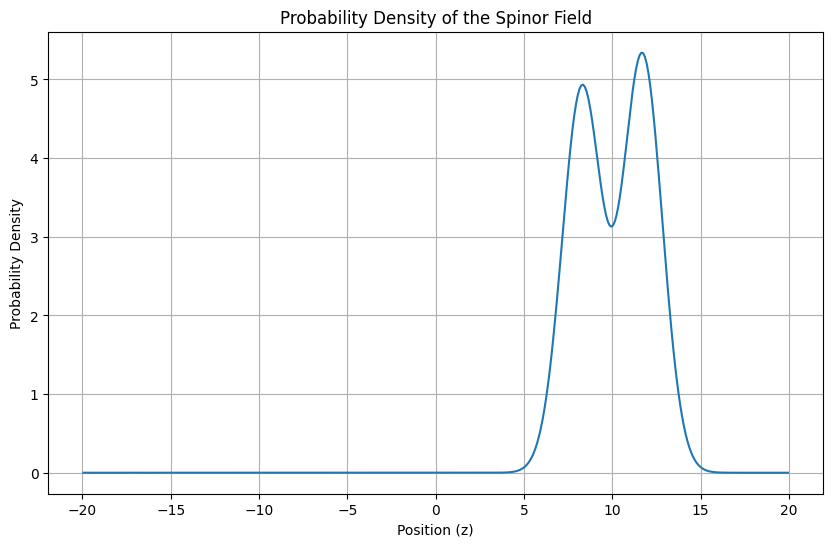

In [12]:
shape = (400,)
spacing = (0.1,)
grid = Grid(shape, spacing)

constant_spinor = ConstantSpinor(momentum=[5, 0, 0])
initial_state = GaussianPacket(constant_spinor, center=[10, 0, 0], spatial_width=1.0)

potential = _core.CoulombPotential(Z=1.0)
boundary_condition = _core.AbsorbingBoundary(strength=0.1)

problem = DiracProblemBuilder() \
    .set_grid(grid) \
    .set_initial_state(initial_state) \
    .set_potential(potential) \
    .set_boundary_condition(boundary_condition) \
    .set_time_parameters(time_step=0.001, total_time=2.0) \
    .build()

solver = DiracSolver(problem)
solver.run_simulation()
solver.plot_probability_density()

## 3. 2D Simulation Example

In [13]:
shape = (100, 100)
spacing = (0.1, 0.1)
grid = Grid(shape, spacing)

constant_spinor = ConstantSpinor(momentum=[5, 5, 0])
initial_state = GaussianPacket(constant_spinor, center=[0, 0, 0], spatial_width=1.0)

potential = _core.FreeParticle()
boundary_condition = _core.PeriodicBoundary()

problem = DiracProblemBuilder() \
    .set_grid(grid) \
    .set_initial_state(initial_state) \
    .set_potential(potential) \
    .set_boundary_condition(boundary_condition) \
    .set_time_parameters(time_step=0.001, total_time=1.0) \
    .build()

solver = DiracSolver(problem)
solver.run_simulation()
solver.plot_probability_density()

ValueError: shapes (3,) and (100,2) not aligned: 3 (dim 0) != 100 (dim 0)